In [1]:
import numpy as np
import os
import lightkurve as lk
import pandas as pd
import matplotlib.pyplot as plt

from astroquery.mast import Catalogs

from leo_vetter.stellar import quadratic_ldc
from leo_vetter.main import TCELightCurve
from leo_vetter.plots import plot_summary, plot_summary_with_diff, plot_diffimages
from leo_vetter.thresholds import check_thresholds
from leo_vetter.pixel import pixel_vetting

from tess_stars2px import tess_stars2px_function_entry as ts2px

### Vetting example for a single transit

This example shows the vetter's performance on a single transit, where you don't know the orbital period. We'll try vetting TOI-1567.01 (TIC-259151170.01), which was observed in sector 18. For simplicity, let's just use the sector 18 light curve.

It's a bit hacky, but we'll set the orbital period to an arbitrary number that is larger than the length of the light curve (e.g., 30 days) (it can be anything as long as it means that there will be no repeated events).

In [2]:
tic = 259151170
per = 30
epo = 1808.52242
dur = 0.172875

# Download light curve
search_result = lk.search_lightcurve(f"TIC {tic}", mission="TESS", author="TESS-SPOC", sector=18)
lc = search_result.download()
lc = lc[~np.isnan(lc["flux"]) & (lc["quality"] == 0)]
transit_mask = lc.create_transit_mask(transit_time=epo, period=per, duration=dur)
lc_flat = lc.flatten(mask=transit_mask)

time = np.asarray(lc_flat["time"].value)
raw = np.asarray(lc["flux"].value)
flux = np.asarray(lc_flat["flux"].value)
flux_err = np.asarray(lc_flat["flux_err"].value)

# Get stellar properties
result = Catalogs.query_criteria(catalog="TIC", ID=tic)
star = {}
for key in ["rad","mass","rho","Teff","logg"]:
    star[key] = float(result[key])
    star["e_"+key] = float(result["e_"+key])

star["u1"], star["u2"] = quadratic_ldc(star["Teff"], star["logg"])

# Pixel vetting also requires the RA and DEC
star["tic"] = tic
star["ra"] = float(result["ra"])
star["dec"] = float(result["dec"])

# Load the TCELightCurve class
tlc = TCELightCurve(tic, time, raw, flux, flux_err, per, epo, dur, planetno=1)

# Check observed sectors
_, _, _, all_sectors, all_cams, all_ccds, _, _, _ = ts2px(tic, star["ra"], star["dec"])

print(all_sectors, all_cams, all_ccds)

[18 58 86] [2 2 2] [4 4 3]


In [3]:
# Flux-level vetting
tlc.compute_flux_metrics(star, verbose=False)

/Users/batfan/miniconda3/envs/exoplanet/lib/python3.12/site-packages/leo_vetter/utils.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mean = np.sum(w * y) / np.sum(w)
/Users/batfan/miniconda3/envs/exoplanet/lib/python3.12/site-packages/leo_vetter/utils.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  err = 1 / np.sqrt(np.sum(w))
/Users/batfan/miniconda3/envs/exoplanet/lib/python3.12/site-packages/leo_vetter/individual.py:112: RuntimeWarning: invalid value encountered in scalar divide
  tlc.metrics["CHI"] = tlc.metrics["MES"] / np.sqrt(chi2 / (tlc.N_transit - 1))


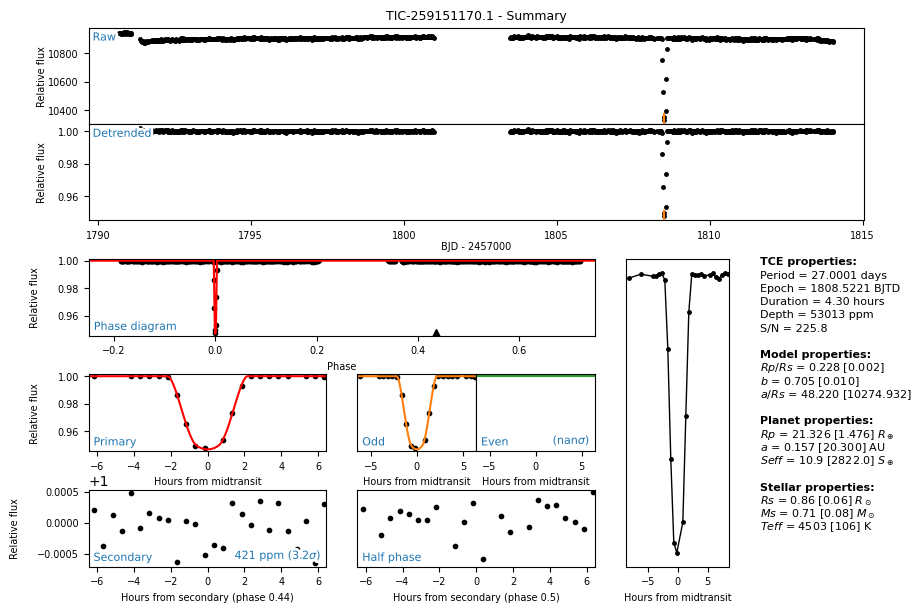

In [4]:
plot_summary(tlc, star, save_fig=False)

In [5]:
# Pixel-level vetting
tdi, good_sectors, good_pixel_data, good_centroids = pixel_vetting(tlc, star, [18])

curl -JL "https://mast.stsci.edu/tesscut/api/v0.1/astrocut?ra=50.3450228969908&dec=52.6925122122649&y=21&x=21&sector=18" --output ./tic259151170_s18.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:02 --:--:--     0
100 9647k  100 9647k    0     0  1833k      0  0:00:05  0:00:05 --:--:-- 4629k


['./tic259151170/tess-s0018-2-4_50.345023_52.692512_21x21_astrocut.fits']
./tic259151170/tess-s0018-2-4_50.345023_52.692512_21x21_astrocut.fits
making difference image for sector 18


In [6]:
print(f"TIC-{tlc.tic}.{tlc.planetno} is offset by {tlc.metrics['offset_qual']:.3f} arcseconds")

TIC-259151170.1 is offset by 1.168 arcseconds


`LEO-Vetter` by default assumes that you have a known period and multiple transits (specifically, at least 3), but single transits don't fall under this case, so we should not use the default thresholds! Specifically, we need to change two thresholds:

- N_transit: default is 3, but we should change this to 1 to allow fewer transits.
- max_SES_to_MES: default is 0.8, but we should change this to np.inf. This metric is used to check if the MES is dominated by a single event. Usually this is a bad sign (e.g., scattered light outlier event) but obviously, a single transit will definitely be dominated by a single event!

We'll do the same as we did in Tutorial 4 to adjust this:

In [7]:
use_thresholds = {
    "MES": 6.2,
    "N_transit": 1, # This was changed
    "SHP": 0.5,
    "MS1": 1,
    "MS2": 1,
    "MS3": 1,
    "chases": 0.78,
    "DMM": 1.5,
    "max_SES_to_MES": np.inf, # This was changed
    "AIC1": -60,
    "AIC2": -30,
    "SWEET": 15,
    "ASYM": 8,
    "CHI": 7.8,
    "frac_gap": 0.5,
    "V_shape": 1.5,
    "size": 22,
    "MS4": 0,
    "MS5": -1,
    "MS6": -1,
    "offset": 15,
}

FA = check_thresholds(tlc.metrics, "FA", verbose=True, thresholds=use_thresholds)
FP = check_thresholds(tlc.metrics, "FP", verbose=True, thresholds=use_thresholds)
if not FA and not FP:
    print(f"TIC-{tlc.tic}.{tlc.planetno} is a planet candidate!")

Passed all FA tests
Passed all FP tests
TIC-259151170.1 is a planet candidate!


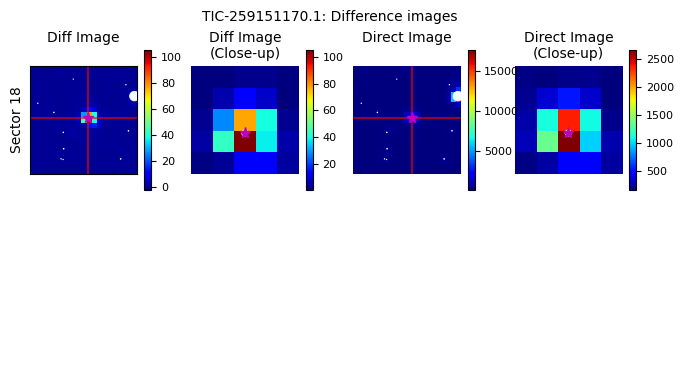

In [8]:
plot_diffimages(tlc.tic, tlc.planetno, tdi, good_sectors, good_pixel_data, save_fig=False)

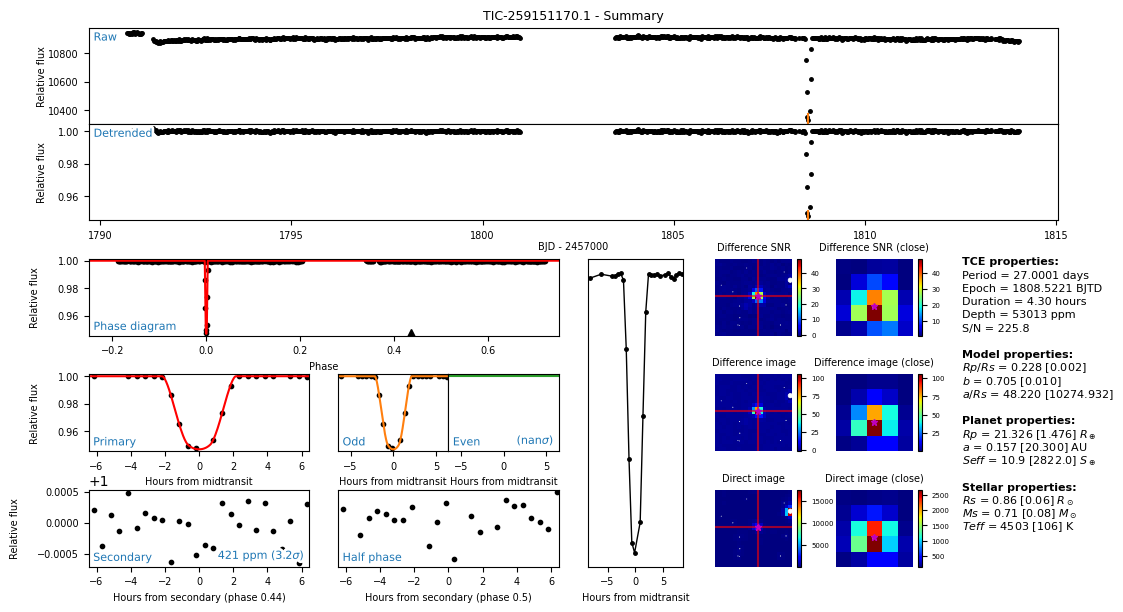

In [9]:
plot_summary_with_diff(tlc, star, tdi, good_pixel_data[0], save_fig=False)